# 2D Grey–Scott Reaction–Diffusion Equation

The Grey–Scott system models two interacting chemical species $u$ and $v$:

$$u_t = \varepsilon_1\,\Delta u + b_1(1 - u) - c_1\,u\,v^2, \quad (x,y) \in (-1,1)^2,\;t \in (0,2)$$
$$v_t = \varepsilon_2\,\Delta v - b_2\,v + c_2\,u\,v^2, \quad (x,y) \in (-1,1)^2,\;t \in (0,2)$$

**Periodic boundary conditions** on both $x$ and $y$.

**Initial conditions:**
$$u_0(x,y) = 1 - e^{-10\left((x+0.05)^2+(y+0.02)^2\right)}$$
$$v_0(x,y) = e^{-10\left((x-0.05)^2+(y-0.02)^2\right)}$$

**Parameters:** $\varepsilon_1=0.2$, $\varepsilon_2=0.1$, $b_1=40$, $b_2=100$, $c_1=c_2=1000$.


In [1]:
import pinns

import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import RegularGridInterpolator

## Domain

$(x,y) \in [-1,1]^2$, $t \in [0,2]$. Periodic BCs on both spatial axes.


In [2]:
domain = pinns.DomainCubic(
    space=[(-1.0, 1.0), (-1.0, 1.0)],  # (x_min, x_max), (y_min, y_max)
    time =[0.0, 0.1],                   # t
)

## PDE Residuals

Two coupled residuals, one per species. The network outputs $[u, v]$.

$$\mathcal{R}_u = u_t - \varepsilon_1(u_{xx} + u_{yy}) - b_1(1-u) + c_1 u v^2 = 0$$
$$\mathcal{R}_v = v_t - \varepsilon_2(v_{xx} + v_{yy}) + b_2 v - c_2 u v^2 = 0$$


In [3]:
import jax

problem = pinns.ProblemStrong(domain=domain, output_names=["u", "v"])

def grey_scott_residual(X, U, params, derivative=None):
    # X columns: 0=x, 1=y, 2=t
    p = params['fixed']
    eps1 = p['eps1'];  eps2 = p['eps2']
    b1   = p['b1'];    b2   = p['b2']
    c1   = p['c1'];    c2   = p['c2']

    u = U[:, 0:1]
    v = U[:, 1:2]

    dt_all   = derivative.all(X, (2,))       # (N, 2): [u_t,  v_t ]
    dxx_all  = derivative.all(X, (0, 0))     # (N, 2): [u_xx, v_xx]
    dyy_all  = derivative.all(X, (1, 1))     # (N, 2): [u_yy, v_yy]

    u_t  = dt_all[:,  0:1];  v_t  = dt_all[:,  1:2]
    u_xx = dxx_all[:, 0:1];  v_xx = dxx_all[:, 1:2]
    u_yy = dyy_all[:, 0:1];  v_yy = dyy_all[:, 1:2]

    uv2 = u * v**2

    res_u = u_t - eps1 * (u_xx + u_yy) - b1 * (1.0 - u) + c1 * uv2
    res_v = v_t - eps2 * (v_xx + v_yy) + b2 * v          - c2 * uv2

    return jnp.concatenate([res_u, res_v], axis=1)   # (N, 2)

problem.add_inner(grey_scott_residual, name="pde")

def u_initial(X):
    x = X[:, 0:1]
    y = X[:, 1:2]
    u0 = 1.0 - jnp.exp(-10.0 * ((x + 0.05)**2 + (y + 0.02)**2))
    v0 =       jnp.exp(-10.0 * ((x - 0.05)**2 + (y - 0.02)**2))   
    return jnp.concatenate([u0, v0], axis=1)   # (N, 2)

problem.add_initial(u_initial, name="initial", outputs=["u", "v"])

problem.add_fixed("eps1", 0.2)

problem.add_fixed("eps2", 0.1)

problem.add_fixed("b1",   40.0)
problem.add_fixed("b2",   100.0)
problem.add_fixed("c1",   1000.0)
problem.add_fixed("c2",   1000.0)


ProblemStrong(domain=DomainCubic, n_dims=3, n_outputs=2, inner=1, boundary=0, initial=2, fixed=['eps1', 'eps2', 'b1', 'b2', 'c1', 'c2'], inferred=[])

### Reference Solution (pseudo-spectral)

Both species are evolved spectrally on a periodic grid. In Fourier space:

$$\partial_t \hat{u}_\mathbf{k} = -\varepsilon_1 |\mathbf{k}|^2 \hat{u}_\mathbf{k} + \mathcal{F}[b_1(1-u) - c_1 u v^2]_\mathbf{k}$$

The linear diffusion $-\varepsilon|\mathbf{k}|^2$ is stiff for large wavenumbers; RK45 with tight tolerances handles it.


In [4]:
eps1_val = 0.2;   eps2_val = 0.1
b1_val   = 40.0;  b2_val   = 100.0
c1_val   = 1000.0; c2_val  = 1000.0

Nx = Ny = 64
Nt = 201        # number of saved snapshots (including t=0)
T  = 2.0
dt = 1e-4       # ETD2RK time step

x_ref = np.linspace(-1, 1, Nx, endpoint=False)
y_ref = np.linspace(-1, 1, Ny, endpoint=False)
t_ref = np.linspace(0, T, Nt)

# 2D wavenumbers for domain length L=2
kx = np.fft.fftfreq(Nx, d=2.0 / Nx) * (2 * np.pi)
ky = np.fft.fftfreq(Ny, d=2.0 / Ny) * (2 * np.pi)
KX, KY = np.meshgrid(kx, ky, indexing='ij')
K2 = KX**2 + KY**2   # |k|²  shape (Nx, Ny)

# ── ETD2RK coefficients (Cox-Matthews, exact linear treatment) ────────────
# For each species:  d û/dt = L*û + N̂(u,v)
# L_u = -eps1*K2,  L_v = -eps2*K2
# Avoid division by zero at k=(0,0) with small epsilon
_eps = 1e-14
Lu = -eps1_val * K2
Lv = -eps2_val * K2

E_u  = np.exp(Lu * dt)
E_v  = np.exp(Lv * dt)
E2_u = np.exp(Lu * dt / 2)
E2_v = np.exp(Lv * dt / 2)

# φ₁(z) = (e^z - 1)/z  (l'Hôpital-safe)
def phi1(z):
    out = np.where(np.abs(z) < 1e-8, 1.0 + z/2 + z**2/6, (np.exp(z) - 1.0) / z)
    return out

phi1_u  = phi1(Lu  * dt)       # (e^{L dt} - 1)/L
phi1_u2 = phi1(Lu  * dt / 2)   # (e^{L dt/2} - 1)/L  × 2  → corrected below
phi1_v  = phi1(Lv  * dt)
phi1_v2 = phi1(Lv  * dt / 2)

# ETD2RK (Hochbruck-Ostermann 2nd-order):
#  k1 = N̂(u_n)
#  û_* = E½ * û_n + (dt/2) * φ₁(L dt/2) * k1
#  k2 = N̂(u_*)
#  û_{n+1} = E * û_n + dt * [ φ₁ * k1  +  φ₂ * (k2 - k1) ]
# where φ₂(z) = (φ₁(z) - 1)/z
def phi2(z):
    p1 = phi1(z)
    return np.where(np.abs(z) < 1e-8, 0.5 + z/6, (p1 - 1.0) / z)

phi2_u = phi2(Lu * dt)
phi2_v = phi2(Lv * dt)

def nonlinear(u_hat, v_hat):
    """Nonlinear spectral RHS for Grey-Scott."""
    u = np.fft.ifft2(u_hat).real
    v = np.fft.ifft2(v_hat).real
    uv2 = u * v**2
    Nu = b1_val * (1.0 - u) - c1_val * uv2
    Nv = -b2_val * v        + c2_val * uv2
    return np.fft.fft2(Nu), np.fft.fft2(Nv)

# Initial conditions
XX, YY = np.meshgrid(x_ref, y_ref, indexing='ij')
u = 1.0 - np.exp(-10.0 * ((XX + 0.05)**2 + (YY + 0.02)**2))
v =       np.exp(-10.0 * ((XX - 0.05)**2 + (YY - 0.02)**2))

u_hat = np.fft.fft2(u)
v_hat = np.fft.fft2(v)

n_steps = int(round(T / dt))
save_every = n_steps // (Nt - 1)

U_ref = np.zeros((Nt, Nx, Ny))
V_ref = np.zeros((Nt, Nx, Ny))
U_ref[0] = u
V_ref[0] = v

snap_idx = 1
print(f"ETD2RK: {n_steps} steps, saving every {save_every} → {Nt} snapshots")
for step in range(1, n_steps + 1):
    # Stage 1: evaluate N at t_n
    Nu1, Nv1 = nonlinear(u_hat, v_hat)
    # Predictor to t + dt/2
    u_star = E2_u * u_hat + (dt / 2) * phi1_u2 * Nu1
    v_star = E2_v * v_hat + (dt / 2) * phi1_v2 * Nv1
    # Stage 2: evaluate N at t + dt/2
    Nu2, Nv2 = nonlinear(u_star, v_star)
    # Corrector to t + dt
    u_hat = E_u * u_hat + dt * (phi1_u * Nu1 + phi2_u * (Nu2 - Nu1))
    v_hat = E_v * v_hat + dt * (phi1_v * Nv1 + phi2_v * (Nv2 - Nv1))

    if step % save_every == 0 and snap_idx < Nt:
        U_ref[snap_idx] = np.fft.ifft2(u_hat).real
        V_ref[snap_idx] = np.fft.ifft2(v_hat).real
        snap_idx += 1

print(f"Done. Saved {snap_idx} snapshots.")
print(f"U_ref range [{U_ref.min():.4f}, {U_ref.max():.4f}]")
print(f"V_ref range [{V_ref.min():.4f}, {V_ref.max():.4f}]")

# Interpolants: X[:,0]=x, X[:,1]=y, X[:,2]=t → (N,2)
_interp_u = RegularGridInterpolator(
    (x_ref, y_ref, t_ref),
    U_ref.transpose(1, 2, 0),   # (Nx, Ny, Nt)
    method='linear', bounds_error=False, fill_value=None,
)
_interp_v = RegularGridInterpolator(
    (x_ref, y_ref, t_ref),
    V_ref.transpose(1, 2, 0),
    method='linear', bounds_error=False, fill_value=None,
)

def uv_reference(X):
    """X[:,0]=x, X[:,1]=y, X[:,2]=t → (N,2)"""
    pts = np.asarray(X)[:, :3]
    u_vals = _interp_u(pts)[:, None]
    v_vals = _interp_v(pts)[:, None]
    return np.concatenate([u_vals, v_vals], axis=1)

problem.add_solution(uv_reference)


/tmp/ipykernel_2929557/17339980.py:35: RuntimeWarning: invalid value encountered in divide
  out = np.where(np.abs(z) < 1e-8, 1.0 + z/2 + z**2/6, (np.exp(z) - 1.0) / z)
/tmp/ipykernel_2929557/17339980.py:51: RuntimeWarning: invalid value encountered in divide
  return np.where(np.abs(z) < 1e-8, 0.5 + z/6, (p1 - 1.0) / z)


ETD2RK: 20000 steps, saving every 100 → 201 snapshots
Done. Saved 201 snapshots.
U_ref range [0.0028, 1.0000]
V_ref range [-0.0000, 0.9972]


ProblemStrong(domain=DomainCubic, n_dims=3, n_outputs=2, inner=1, boundary=0, initial=2, fixed=['eps1', 'eps2', 'b1', 'b2', 'c1', 'c2'], inferred=[])

## Network Architecture

Input is 3D $(x, y, t)$, output is 2D $(u, v)$.
`tanh` output activation keeps both concentrations in $[0, 1]$,
consistent with the physical range of the Grey–Scott system.


In [5]:
network = pinns.ModelBase(domain, 2)

network.add(pinns.Normalize())
network.add(pinns.PeriodicEmbedding(["x", "y"]))
network.add(pinns.FourierFeatures(256, sigma=1.0))
network.add(pinns.PirateNet(256, 3, rwf_mu=0.5, rwf_sigma=0.1, output_activation="sigmoid"))


ModelBase(output_dim=2)
  [Normalize_0] Normalize(n_coord=3, n_context=0, context_scaled=False)
  [PeriodicEmbedding_1] PeriodicEmbedding([axis=0 freq=3.1416 k=[1], axis=1 freq=3.1416 k=[1]], input_dim=3, output_dim=5)
  [RandomFourierFeatures_2] RandomFourierFeatures(fourier_input_dim=5, n_features=256, sigma=1.0, adaptive=True)
  [PirateNet_3] PirateNet(input_dim=512, hidden_dim=256, n_blocks=3, output_dim=2, output_activation='sigmoid')

## Training

Curriculum over $t$: 10 stages from $t_\text{max}=0.2$ to $2.0$, 5000 epochs each.
Optimizer is reset at each stage to clear stale momentum from the previous (smaller) window.


Starting training for 500000 epochs (JIT-compiled)...


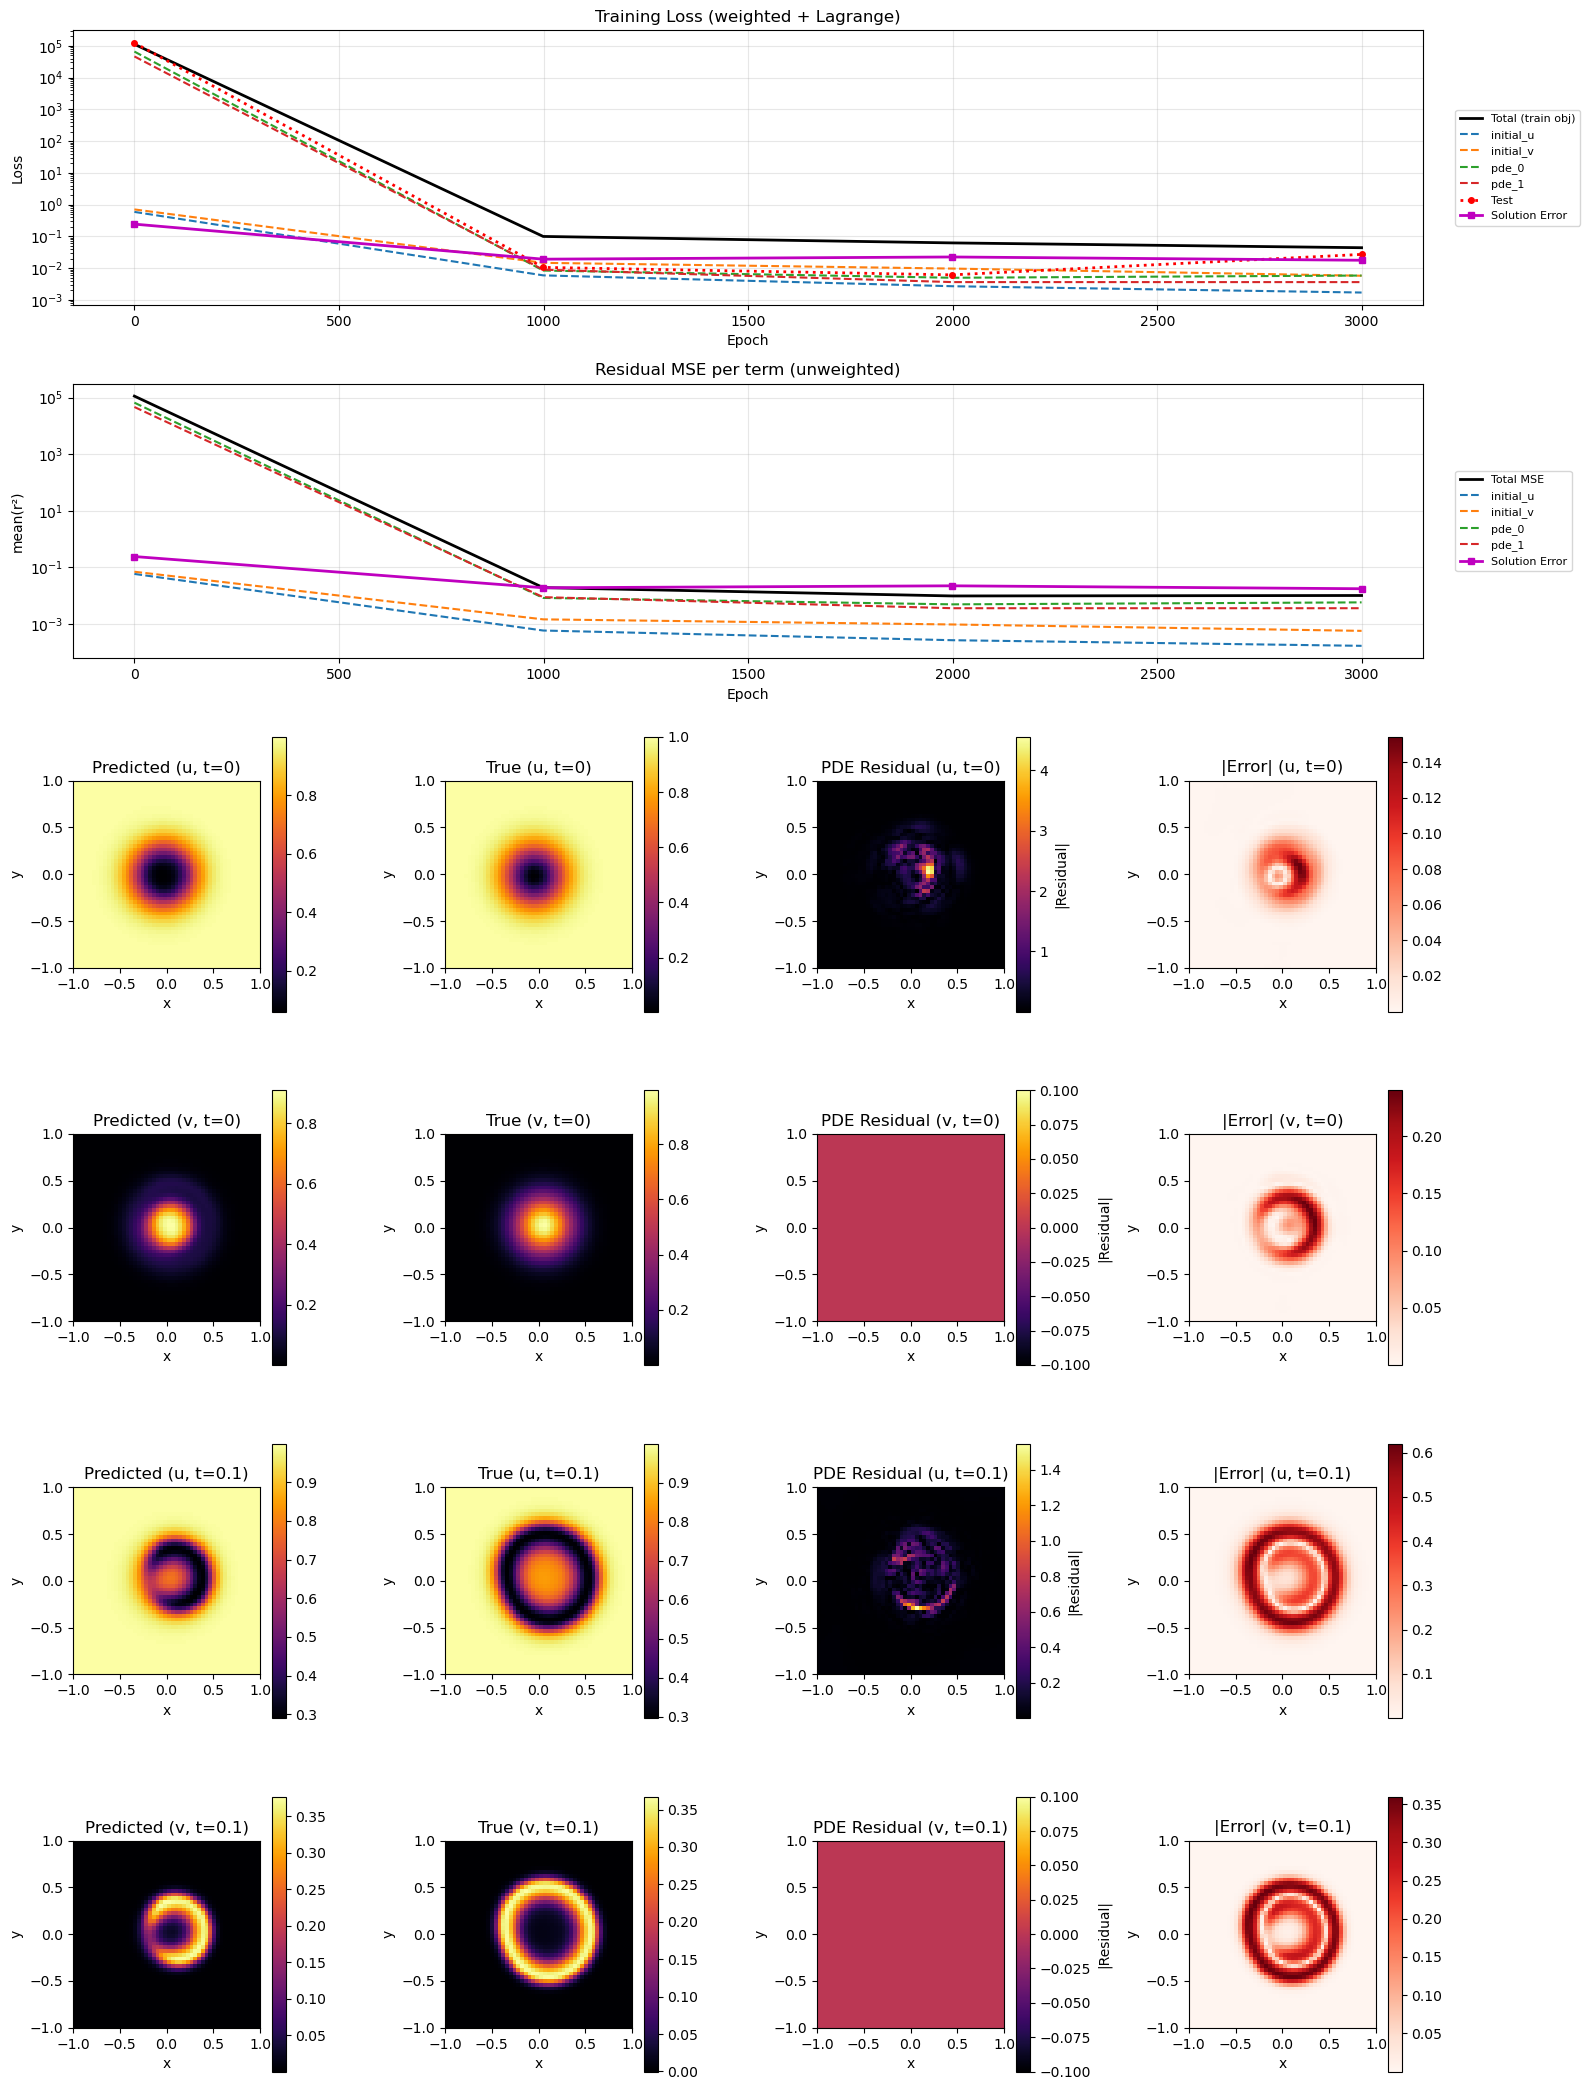

Epoch 0/500000 | Loss: 1.13e+05 | MSE: 1.13e+05 | Terms: [initial_u: 5.90e-02, initial_v: 7.06e-02, pde_0: 6.62e+04, pde_1: 4.65e+04] | Test Loss: 1.25e+05 | Error: 2.43e-01 | Time: 0.0s
Epoch 1000/500000 | Loss: 9.95e-02 | MSE: 1.94e-02 | Terms: [initial_u: 5.91e-04, initial_v: 1.47e-03, pde_0: 8.38e-03, pde_1: 8.92e-03] | Test Loss: 1.05e-02 | Error: 1.91e-02 | Time: 58.5s
Epoch 2000/500000 | Loss: 6.22e-02 | MSE: 9.84e-03 | Terms: [initial_u: 2.69e-04, initial_v: 9.67e-04, pde_0: 4.97e-03, pde_1: 3.63e-03] | Test Loss: 6.13e-03 | Error: 2.24e-02 | Time: 95.3s
Epoch 3000/500000 | Loss: 4.39e-02 | MSE: 1.02e-02 | Terms: [initial_u: 1.70e-04, initial_v: 5.75e-04, pde_0: 5.84e-03, pde_1: 3.63e-03] | Test Loss: 2.71e-02 | Error: 1.77e-02 | Time: 132.1s


In [ ]:
trainer = pinns.Trainer(problem, network)

trainer.compile(
    problem = {
        "pde":      {"train": 4096, "test": 10, "weight": 1.0},
        "initial":  {"train": 1000, "test": 10, "weight": 10.0},
    },
    optimizer=pinns.SOAPOptimizer(),
    schedulers=[
        pinns.SchedulerResample(1),
        pinns.SchedulerCausal(term="pde", tol=1.0, n_chunks=16, t_col=2),
    ],
    epochs= 500000,

    print_each = 1000,
)

trainer.train()